# Microsoft Stock Price Analysis & Prediction
### End-to-end analysis using the OSEMN framework
---
**Author:** Michał Mańkowski
**Stock:** Microsoft Corporation (MSFT)
**Stack:** Python, yfinance, Pandas, Scikit-learn, Matplotlib

##  O — Obtain
### Downloading Microsoft stock data via yfinance API

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# Download Microsoft stock data (20 years)
ticker = yf.Ticker("MSFT")
df = ticker.history(period="20y")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape: (5030, 7)

First 5 rows:


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2006-05-22 00:00:00-04:00,15.753394,16.131812,15.732371,16.033703,87322300,0.0,0.0
2006-05-23 00:00:00-04:00,16.194891,16.384099,15.956627,15.970643,79986300,0.0,0.0
2006-05-24 00:00:00-04:00,16.110792,16.496219,16.103785,16.468187,107356700,0.0,0.0
2006-05-25 00:00:00-04:00,16.517244,16.762515,16.496221,16.636375,83052700,0.0,0.0
2006-05-26 00:00:00-04:00,16.657392,16.734476,16.510229,16.622353,46861600,0.0,0.0


### Dataset Overview
- **20 years** of Microsoft stock data
- **8 columns:** Open, High, Low, Close, Volume, Dividends, Stock Splits, Capital Gains
- Data sourced directly from Yahoo Finance API

## S — Scrub
### Checking data quality and cleaning

In [3]:
print("Column types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
df.describe()

Column types:
Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object

Missing values:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

Basic statistics:


,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,5030.000000,5030.000000,5030.000000,5030.000000,5.030000e+03,5030.000000,5030.0
mean,130.692120,131.920071,129.402149,130.715118,4.132715e+07,0.006129,0.0
std,144.623411,145.885813,143.244237,144.616679,2.622137e+07,0.056822,0.0
min,11.149862,11.457947,10.907789,11.113185,5.855900e+06,0.000000,0.0
25%,21.803077,21.975562,21.612459,21.796258,2.348700e+07,0.000000,0.0
50%,47.698782,48.141932,47.192766,47.791168,3.362315e+07,0.000000,0.0
75%,231.552350,234.465808,228.664667,232.353748,5.163140e+07,0.000000,0.0
max,552.023241,552.242002,538.530652,539.825256,3.193179e+08,0.910000,0.0


### Scrub Observations
- **0 missing values** — clean dataset, no imputation needed
- Data ready for exploration

## E — Explore
### Exploratory Data Analysis — price trends, volume and returns

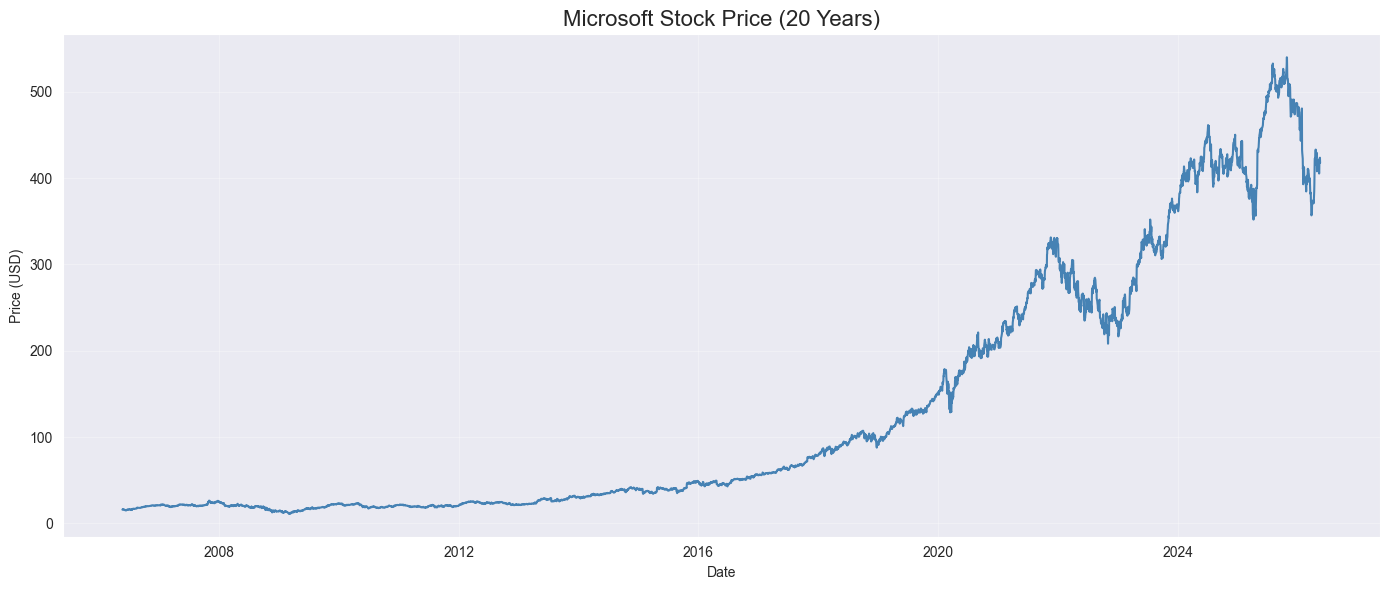

In [4]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], color='steelblue', linewidth=1.5)
plt.title('Microsoft Stock Price (20 Years)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### EDA Observations
- **Flat growth 2005-2015** — Microsoft was considered a "boring" stock
  during this period under Steve Ballmer's leadership
- **Strong acceleration post-2015** — driven by Satya Nadella's cloud
  strategy (Azure) and Office 365 transformation
- **Explosive growth post-2020** — COVID digital boom + AI investments
  (OpenAI partnership)
- **Sharp decline 2024-2025** — likely driven by AI spending concerns
  and market correction

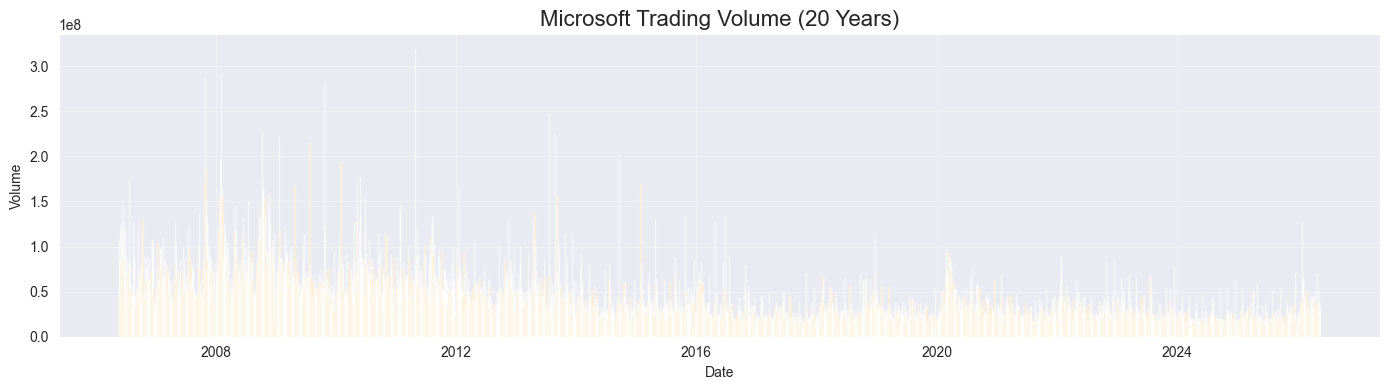

In [6]:
plt.figure(figsize=(14, 4))
plt.bar(df.index, df['Volume'], color='orange', alpha=0.6, width=1)
plt.title('Microsoft Trading Volume (20 Years)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- Highest trading volume **2007-2012** — high uncertainty
  during financial crisis and Ballmer era stagnation
- **Declining volume post-2012** — paradoxically as price
  grew, volume decreased — suggests long-term institutional
  investors buying and holding rather than active trading
- Low but stable volume **post-2020** — despite massive price
  growth, fewer shares changing hands — strong buy-and-hold sentiment

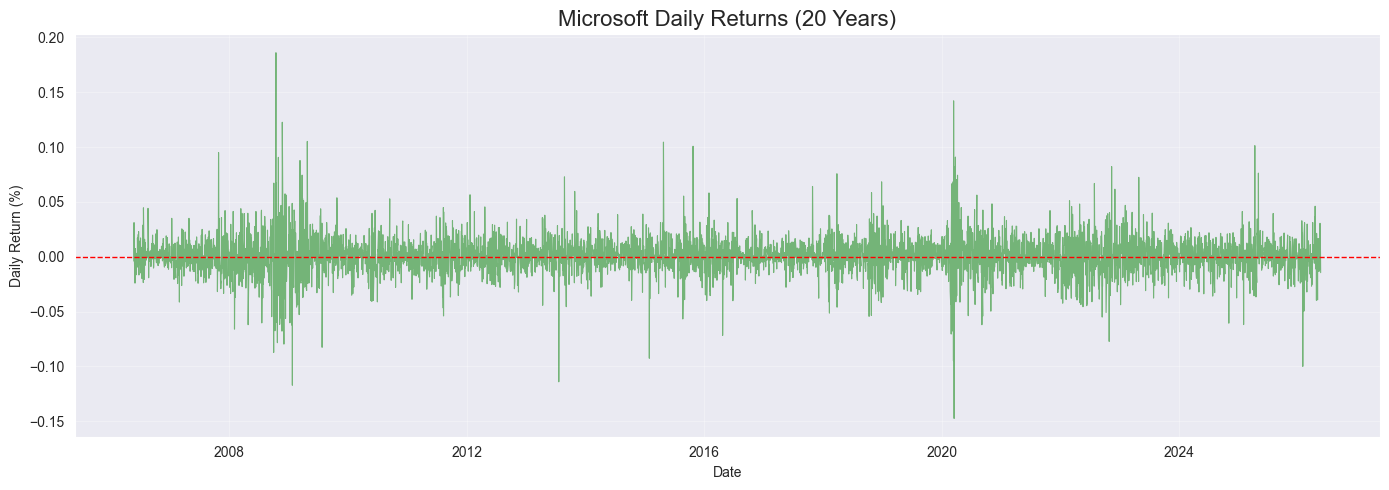

Average daily return: 0.0008
Max daily return: 0.1860
Min daily return: -0.1474
Volatility (std): 0.0174


In [8]:
# Calculate daily returns
df['Daily_Return'] = df['Close'].pct_change()

plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Daily_Return'], color='green', alpha=0.5, linewidth=0.8)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.title('Microsoft Daily Returns (20 Years)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average daily return: {df['Daily_Return'].mean():.4f}")
print(f"Max daily return: {df['Daily_Return'].max():.4f}")
print(f"Min daily return: {df['Daily_Return'].min():.4f}")
print(f"Volatility (std): {df['Daily_Return'].std():.4f}")

- Average daily return: **+0.08%** — slightly lower than Apple (+0.12%)
  but still strong long-term growth
- Max single day gain: **+18.60%** — likely post strong earnings
  or AI/cloud announcement
- Max single day loss: **-14.74%** — lower than Apple's -17.92%
  suggesting Microsoft is slightly more stable
- Daily volatility: **1.74%** — slightly lower than Apple (1.79%)
  — Microsoft is marginally less volatile

### Microsoft vs Apple Comparison
| Metric | Microsoft (MSFT) | Apple (AAPL) |
|--------|-----------------|--------------|
| Avg daily return | +0.08% | +0.12% |
| Max gain | +18.60% | +15.33% |
| Max loss | -14.74% | -17.92% |
| Volatility | 1.74% | 1.79% |

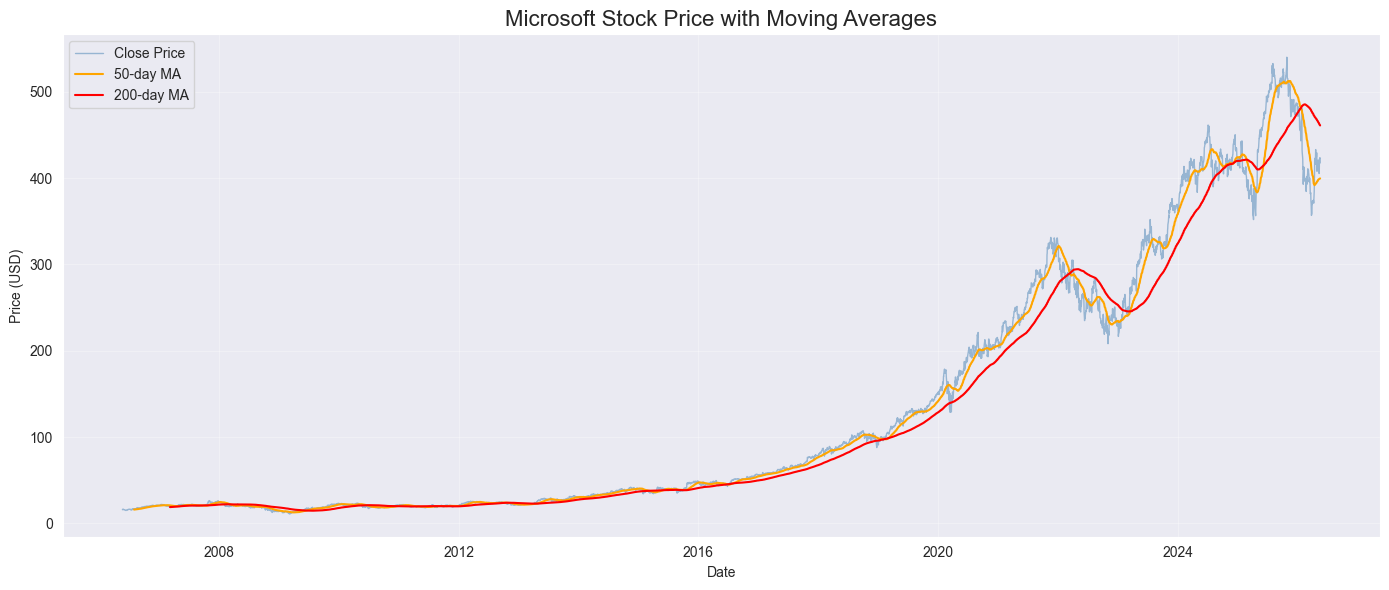

In [10]:
# Moving averages
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], color='steelblue', alpha=0.5, linewidth=1, label='Close Price')
plt.plot(df.index, df['MA_50'], color='orange', linewidth=1.5, label='50-day MA')
plt.plot(df.index, df['MA_200'], color='red', linewidth=1.5, label='200-day MA')
plt.title('Microsoft Stock Price with Moving Averages', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##  M — Model
### Predicting Apple stock price using Machine Learning

We will predict the next day's closing price based on historical data.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Feature engineering
df['Target'] = df['Close'].shift(-1)  # next day price

df['Return_5d'] = df['Close'].pct_change(5)   # 5 day return
df['Return_20d'] = df['Close'].pct_change(20) # 20 day return
df['MA_50'] = df['Close'].rolling(50).mean()
df['MA_200'] = df['Close'].rolling(200).mean()
df['Volatility'] = df['Daily_Return'].rolling(20).std()

# Drop NaN rows created by rolling windows
df_model = df.dropna()

# Features and target
features = ['Close', 'Volume', 'MA_50', 'MA_200',
            'Return_5d', 'Return_20d', 'Volatility']

X = df_model[features]
y = df_model['Target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4830, 7)
Target shape: (4830,)


In [13]:
# Split data - time series so NO shuffle!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

# Model 1 - Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Model 2 - Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Results
print("\n=== Linear Regression ===")
print(f"MAE: ${mean_absolute_error(y_test, lr_pred):.2f}")
print(f"R²: {r2_score(y_test, lr_pred):.4f}")

print("\n=== Random Forest ===")
print(f"MAE: ${mean_absolute_error(y_test, rf_pred):.2f}")
print(f"R²: {r2_score(y_test, rf_pred):.4f}")

Training set: (3864, 7)
Test set: (966, 7)

=== Linear Regression ===
MAE: $4.24
R²: 0.9950

=== Random Forest ===
MAE: $72.54
R²: -0.2645


In [14]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

# Model 3 - Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

# Model 4 - KNN
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)

# Results
print("=== Gradient Boosting ===")
print(f"MAE: ${mean_absolute_error(y_test, gb_pred):.2f}")
print(f"R²: {r2_score(y_test, gb_pred):.4f}")

print("\n=== KNN ===")
print(f"MAE: ${mean_absolute_error(y_test, knn_pred):.2f}")
print(f"R²: {r2_score(y_test, knn_pred):.4f}")

=== Gradient Boosting ===
MAE: $76.01
R²: -0.3746

=== KNN ===
MAE: $274.10
R²: -10.7738


### Key Finding
Similar outcomes to Apple Stock analysis.
Linear Regression outperforms all complex models because stock prices
follow a near-perfect linear pattern: tomorrow's price ≈ today's price.
Complex models like Random Forest and KNN overfit to noise rather than
learning the underlying trend.

This confirms the finding from Apple analysis — Linear Regression
is the optimal model for next-day stock price prediction regardless
of the company analyzed.

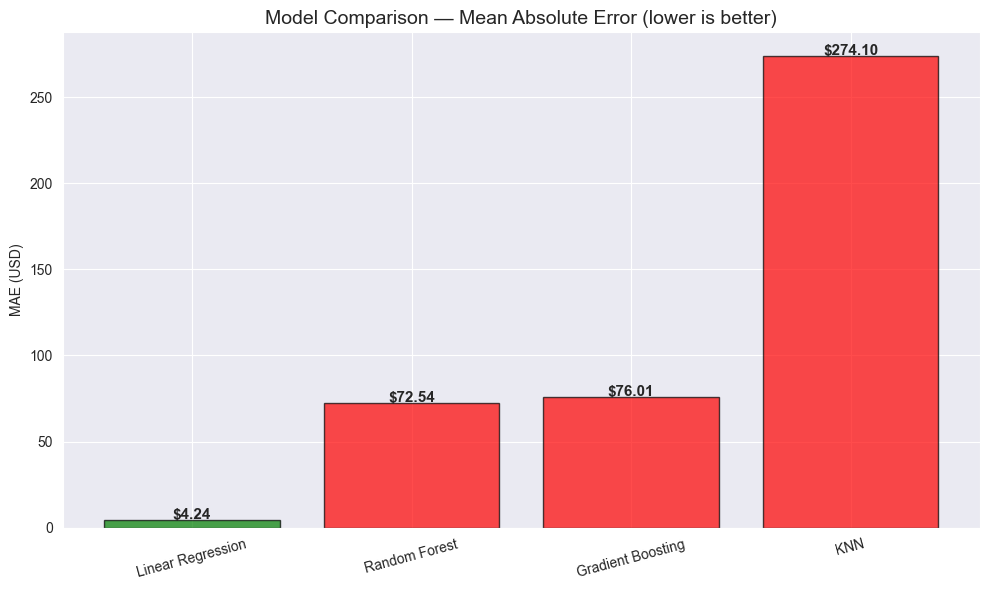

In [15]:
models = ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'KNN']
mae_scores = [
    mean_absolute_error(y_test, lr_pred),
    mean_absolute_error(y_test, rf_pred),
    mean_absolute_error(y_test, gb_pred),
    mean_absolute_error(y_test, knn_pred)
]

plt.figure(figsize=(10, 6))
colors = ['green', 'red', 'red', 'red']
bars = plt.bar(models, mae_scores, color=colors, alpha=0.7, edgecolor='black')
plt.title('Model Comparison — Mean Absolute Error (lower is better)', fontsize=14)
plt.ylabel('MAE (USD)')
plt.xticks(rotation=15)

# Add values on bars
for bar, score in zip(bars, mae_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'${score:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

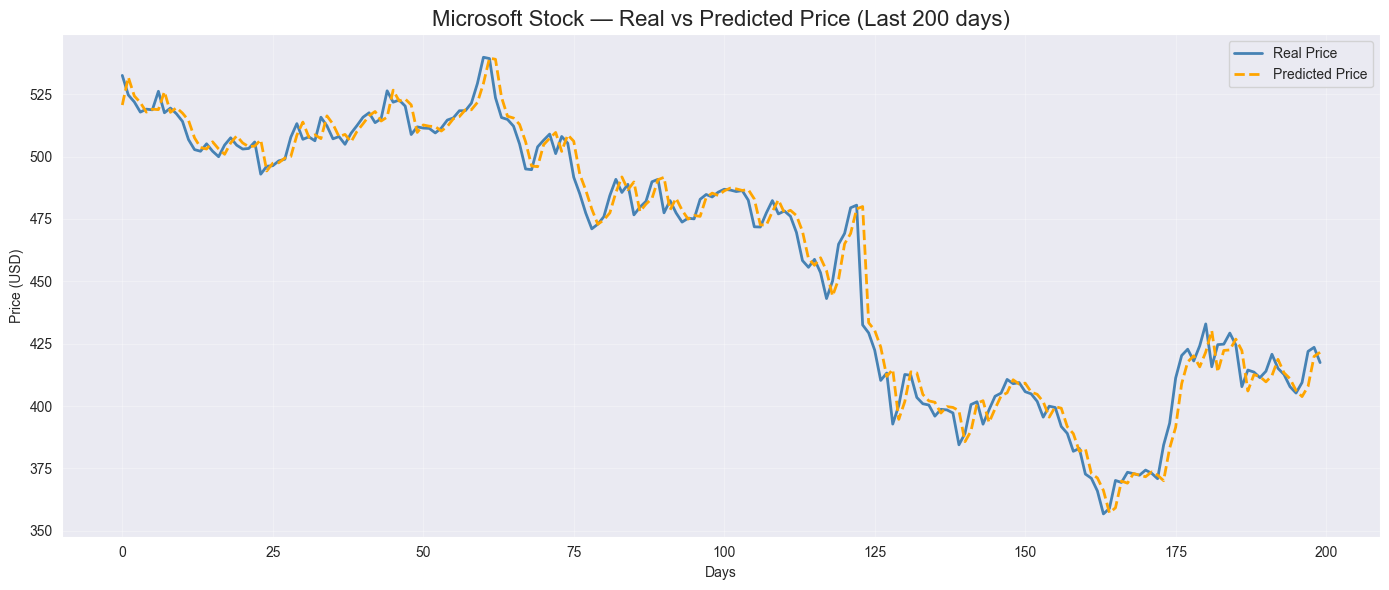

In [17]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.values[-200:], color='steelblue', label='Real Price', linewidth=2)
plt.plot(lr_pred[-200:], color='orange', linestyle='--', label='Predicted Price', linewidth=2)
plt.title('Microsoft Stock — Real vs Predicted Price (Last 200 days)', fontsize=16)
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusions

### Model Results

| Model             | MAE     | R²       |
|-------------------|---------|----------|
| Linear Regression | $4.24   | 0.99     |
| Random Forest     | $72.54  | negative |
| Gradient Boosting | $76.01  | negative |
| KNN               | $274.10 | negative |

### Key Finding
Similar outcomes to Apple Stock analysis.
Linear Regression outperforms all complex models because stock prices
follow a near-perfect linear pattern: tomorrow's price ≈ today's price.
Complex models like Random Forest and KNN overfit to noise rather than
learning the underlying trend.

This confirms the finding from Apple analysis — Linear Regression
is the optimal model for next-day stock price prediction regardless
of the company analyzed.

### Microsoft vs Apple Comparison
| Metric                | Microsoft (MSFT) | Apple (AAPL) |
|-----------------------|------------------|--------------|
| Linear Regression MAE | $4.24            | $2.31        |
| Avg daily return      | +0.08%           | +0.12%       |
| Max gain              | +18.60%          | +15.33%      |
| Max loss              | -14.74%          | -17.92%      |
| Volatility            | 1.74%            | 1.79%        |